# Swahili Sentiment Analysis — Baseline Models

Trains Logistic Regression, Naive Bayes, and Linear SVM using TF-IDF features.

> **Prerequisite:** Run `01_preprocessing.ipynb` first.

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '..')

%matplotlib inline
sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Processed Data

In [2]:
df = pd.read_csv('../data/processed/cleaned_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (453, 6)


,tweet,label,clean_text,original_len,cleaned_len,label_encoded
0,Leo nimepata kitambulisho changu cha taifa Asa...,positive,leo nimepata kitambulisho changu cha taifa asa...,54,54,2
1,Asante na tafadhali subiri tutawasiliana nawe ...,positive,asante na tafadhali subiri tutawasiliana nawe ...,67,67,2
2,Takwimu zinaonyesha katika kila watoto 100 27 ...,neutral,takwimu zinaonyesha katika kila watoto wanapat...,85,75,1
3,Kwa hiyo kama ilivyokuja kwenye aya hiyo ni ju...,neutral,kwa hiyo kama ilivyokuja kwenye aya hiyo ni ju...,228,228,1
4,Sio watu wazuri awa Nakutana nao FA Cup nawafa...,negative,sio watu wazuri awa nakutana nao fa cup nawafa...,54,54,0


In [3]:
X = df['clean_text'].fillna('').tolist()
y = df['label_encoded'].tolist()
print(f'Features: {len(X):,} samples')

Features: 453 samples


## 2. Train / Test Split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Train: 362  |  Test: 91


## 3. TF-IDF Vectorisation

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)
print(f'Feature matrix: {X_train_tfidf.shape}')

Feature matrix: (362, 979)


## 4. Train Models

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

LABEL_NAMES = ['negative', 'neutral', 'positive']

def evaluate(name, y_true, y_pred):
    print(f'\n── {name} ──────────────────────────────────────')
    print(classification_report(y_true, y_pred, target_names=LABEL_NAMES))
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1 Score (W)': f1_score(y_true, y_pred, average='weighted'),
        'Precision (W)': precision_score(y_true, y_pred, average='weighted'),
        'Recall (W)': recall_score(y_true, y_pred, average='weighted'),
    }

results = []
preds   = {}

In [7]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs',
                        multi_class='multinomial', random_state=42)
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)
results.append(evaluate('Logistic Regression', y_test, lr_pred))
preds['Logistic Regression'] = lr_pred


── Logistic Regression ──────────────────────────────────────
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        10
     neutral       0.61      0.96      0.75        54
    positive       0.67      0.15      0.24        27

    accuracy                           0.62        91
   macro avg       0.43      0.37      0.33        91
weighted avg       0.56      0.62      0.52        91



c:\Users\Tsheg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Tsheg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Tsheg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Tsheg\anaconda3\Lib\site-packag

In [8]:
# Naive Bayes
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train)
nb_pred = nb.predict(X_test_tfidf)
results.append(evaluate('Naive Bayes', y_test, nb_pred))
preds['Naive Bayes'] = nb_pred


── Naive Bayes ──────────────────────────────────────
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        10
     neutral       0.62      0.83      0.71        54
    positive       0.35      0.22      0.27        27

    accuracy                           0.56        91
   macro avg       0.32      0.35      0.33        91
weighted avg       0.47      0.56      0.50        91



In [9]:
# Linear SVM
svm = LinearSVC(C=1.0, random_state=42, max_iter=2000)
svm.fit(X_train_tfidf, y_train)
svm_pred = svm.predict(X_test_tfidf)
results.append(evaluate('Linear SVM', y_test, svm_pred))
preds['Linear SVM'] = svm_pred


── Linear SVM ──────────────────────────────────────
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        10
     neutral       0.62      0.83      0.71        54
    positive       0.37      0.26      0.30        27

    accuracy                           0.57        91
   macro avg       0.33      0.36      0.34        91
weighted avg       0.48      0.57      0.51        91



c:\Users\Tsheg\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\Tsheg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Tsheg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Tsheg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-

## 5. Confusion Matrices

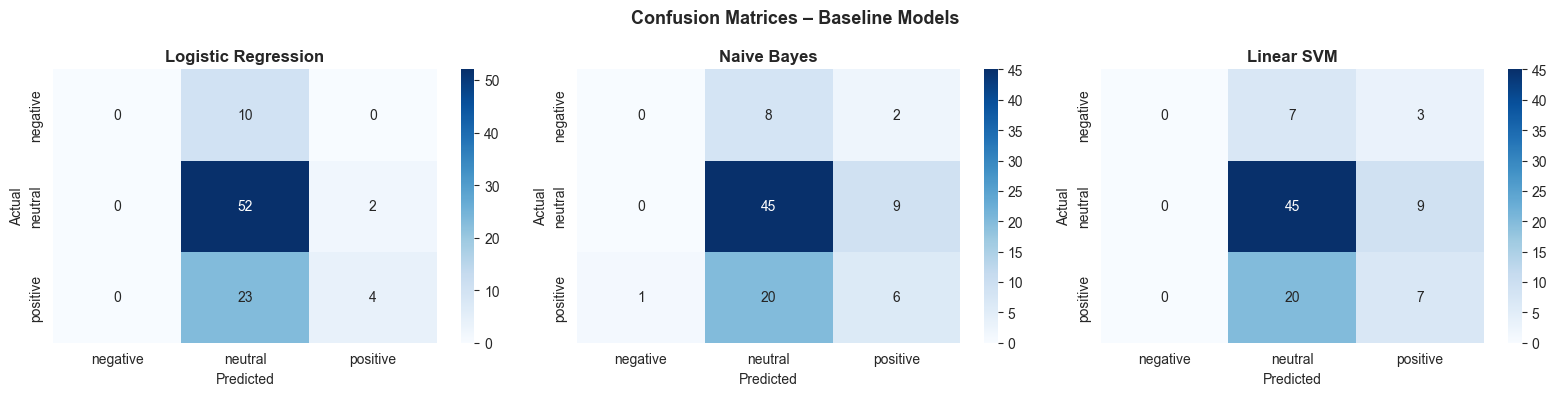

In [10]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices – Baseline Models', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/confusion_baselines.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Results Summary

              Model  Accuracy  F1 Score (W)  Precision (W)  Recall (W)
Logistic Regression    0.6154        0.5159         0.5608      0.6154
        Naive Bayes    0.5604        0.5014         0.4705      0.5604
         Linear SVM    0.5714        0.5142         0.4802      0.5714


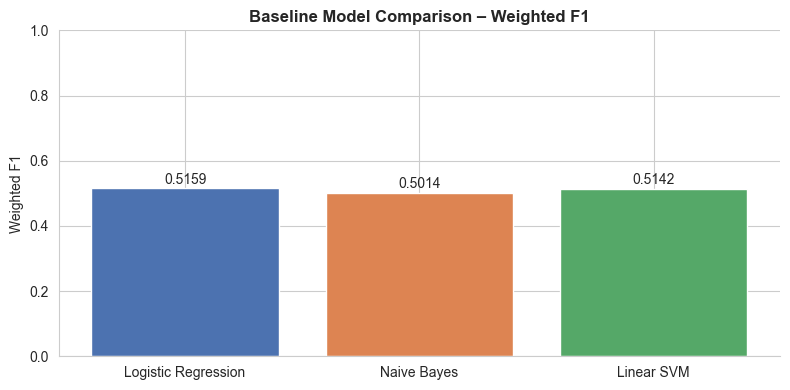

In [11]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = ax.bar(results_df['Model'], results_df['F1 Score (W)'], color=colors, edgecolor='white')
for bar, val in zip(bars, results_df['F1 Score (W)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_title('Baseline Model Comparison – Weighted F1', fontweight='bold')
ax.set_ylabel('Weighted F1')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/baseline_comparison.png', dpi=150)
plt.show()

## 7. Save Results & Models

In [12]:
import joblib

os.makedirs('../results', exist_ok=True)
os.makedirs('../models', exist_ok=True)

results_df.to_csv('../results/baseline_results.csv', index=False)
joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
joblib.dump(lr,  '../models/logistic_regression.pkl')
joblib.dump(nb,  '../models/naive_bayes.pkl')
joblib.dump(svm, '../models/svm.pkl')

print('Saved:')
print('  results/baseline_results.csv')
print('  models/tfidf_vectorizer.pkl')
print('  models/logistic_regression.pkl')
print('  models/naive_bayes.pkl')
print('  models/svm.pkl')

Saved:
  results/baseline_results.csv
  models/tfidf_vectorizer.pkl
  models/logistic_regression.pkl
  models/naive_bayes.pkl
  models/svm.pkl
